# ImageNet-32: CNN vs. Transformer — Results

This notebook does **no training**. It reads the per-epoch metrics each run wrote to
`runs/<tag>.jsonl` and turns them into the comparison. Re-run it any time; it picks up whatever
runs exist on disk.

## The question

A **CNN** has locality and translation-equivariance hardwired into its structure — free, correct
assumptions about images that it never has to learn. A **Vision Transformer** has almost none of
that: it must learn spatial structure from the data itself.

So the CNN should win when data is scarce, and the Transformer should overtake it when data is
plentiful. **Where is the crossover?** We have two points on that curve:

| dataset | images | classes |
|---|---|---|
| CIFAR-10 (`../a1-cv/cifar10_train.ipynb`) | 50,000 | 10 |
| ImageNet-32 (here) | **1,281,167** | **1,000** |

Same 32×32 image size, so the models port over unchanged — only `num_classes` moves.

In [1]:
import json, os, glob
import matplotlib.pyplot as plt

# Where the runs live: RUNS holds the per-epoch metrics each training run appended (one JSON object
# per line), LOGS holds its plain-text log. This notebook only reads them back -- it never trains.
RUNS, LOGS = 'runs', 'logs'

def used_mixup(tag):
    """Did this run use mixup/CutMix? Read it from the run's own log -- never assume."""
    try:
        for line in open(f'{LOGS}/{tag}.log', errors='replace'):
            if 'strong aug' in line:
                return 'True' in line
    except OSError:
        pass

    # None, not False: the run predates the flag being logged, so we genuinely don't know.
    return None

# load: read one run's jsonl into the handful of summary numbers the tables and plots need. best_top5
# and best_epoch are read at the epoch of peak top1, so all three describe one moment, not three.
def load(tag):
    rows = [json.loads(l) for l in open(f'{RUNS}/{tag}.jsonl') if l.strip()]
    top1 = [r['val']['top1'] for r in rows]
    i = top1.index(max(top1))
    return {
        'tag': tag,
        'epochs': rows[-1]['epoch'],
        'best_top1': max(top1),
        'best_top5': rows[i]['val']['top5'],
        'best_epoch': i + 1,
        'final_train': rows[-1]['train']['top1'],
        'minutes': rows[-1]['elapsed'] / 60,
        'mixup': used_mixup(tag),
        'val_curve': top1,
        'train_curve': [r['train']['top1'] for r in rows],
    }

# Load every run on disk, keyed by tag (the filename without .jsonl). Skip the cifar* and smoke* runs:
# this notebook is the ImageNet-32 story, and those belong to other notebooks.
runs = {t: load(t) for p in sorted(glob.glob(f'{RUNS}/*.jsonl'))
        for t in [os.path.basename(p)[:-6]] if t.startswith('imagenet32_')}
print(f'{len(runs)} runs found: {", ".join(runs)}')

10 runs found: imagenet32_resnet18, imagenet32_resnet18_60ep, imagenet32_resnet18_aug60, imagenet32_resnet18_clip, imagenet32_resnet18_overnight, imagenet32_resnet18_v2, imagenet32_resnet50, imagenet32_vit, imagenet32_vit_40ep, imagenet32_vit_base


In [2]:
# The scoreboard, sorted by accuracy. The architecture is what we're testing, but epochs and mixup
# are two advantages that have to be controlled for before any architectural claim is allowed -- so
# both stay as columns here, nothing hidden. FAMILY tags each run CNN or ViT from its name.
FAMILY = lambda t: 'ViT' if t.removeprefix('imagenet32_').startswith('vit') else 'CNN'

# Header row, then a rule under it.
print(f'{"run":18s} {"family":6s} {"epochs":>6s} {"mixup":>5s} {"top-1":>7s} {"top-5":>7s} {"min":>5s}')
print('-' * 66)

# One row per run, best first. mixup is unknown for older runs, so map True/False/None to yes/no/?.
for r in sorted(runs.values(), key=lambda r: -r['best_top1']):
    mix = {True: 'yes', False: 'no', None: '?'}[r['mixup']]
    print(f'{r["tag"]:18s} {FAMILY(r["tag"]):6s} {r["epochs"]:6d} {mix:>5s} '
          f'{r["best_top1"]:7.2%} {r["best_top5"]:7.2%} {r["minutes"]:5.0f}')

# The headline the notebook is about: the single best CNN against the single best ViT, and which
# family leads. A reference number from the literature follows, to place our absolute scores.
best_cnn = max((r for t, r in runs.items() if FAMILY(t) == 'CNN'), key=lambda r: r['best_top1'])
best_vit = max((r for t, r in runs.items() if FAMILY(t) == 'ViT'), key=lambda r: r['best_top1'])
print(f'\nbest CNN: {best_cnn["tag"]:16s} {best_cnn["best_top1"]:.2%}')
print(f'best ViT: {best_vit["tag"]:16s} {best_vit["best_top1"]:.2%}')
print(f'   {"ViT" if best_vit["best_top1"] > best_cnn["best_top1"] else "CNN"} ahead by '
      f'{abs(best_vit["best_top1"] - best_cnn["best_top1"]):.2%} points')
print('\nreference: WRN-28-10 = 59.0% top-1 / 81.1% top-5 (Chrabaszcz et al. 2017, much larger model)')

run                family epochs mixup   top-1   top-5   min
------------------------------------------------------------------
imagenet32_vit     ViT        40   yes  43.01%  66.51%    58
imagenet32_vit_40ep ViT        40   yes  42.33%  66.68%    63
imagenet32_resnet18 CNN        40    no  41.69%  66.84%    39
imagenet32_vit_base ViT        40   yes  41.47%  63.02%   311
imagenet32_resnet50 CNN        40    no  41.16%  66.06%   107
imagenet32_resnet18_60ep CNN        60    no  37.06%  62.58%    58
imagenet32_resnet18_clip CNN        40    no  36.86%  62.30%    26
imagenet32_resnet18_v2 CNN        40    no  36.84%  62.45%    44
imagenet32_resnet18_overnight CNN        40     ?  36.71%  62.42%    27
imagenet32_resnet18_aug60 CNN        60   yes  33.91%  59.43%    59

best CNN: imagenet32_resnet18 41.69%
best ViT: imagenet32_vit   43.01%
   ViT ahead by 1.32% points

reference: WRN-28-10 = 59.0% top-1 / 81.1% top-5 (Chrabaszcz et al. 2017, much larger model)


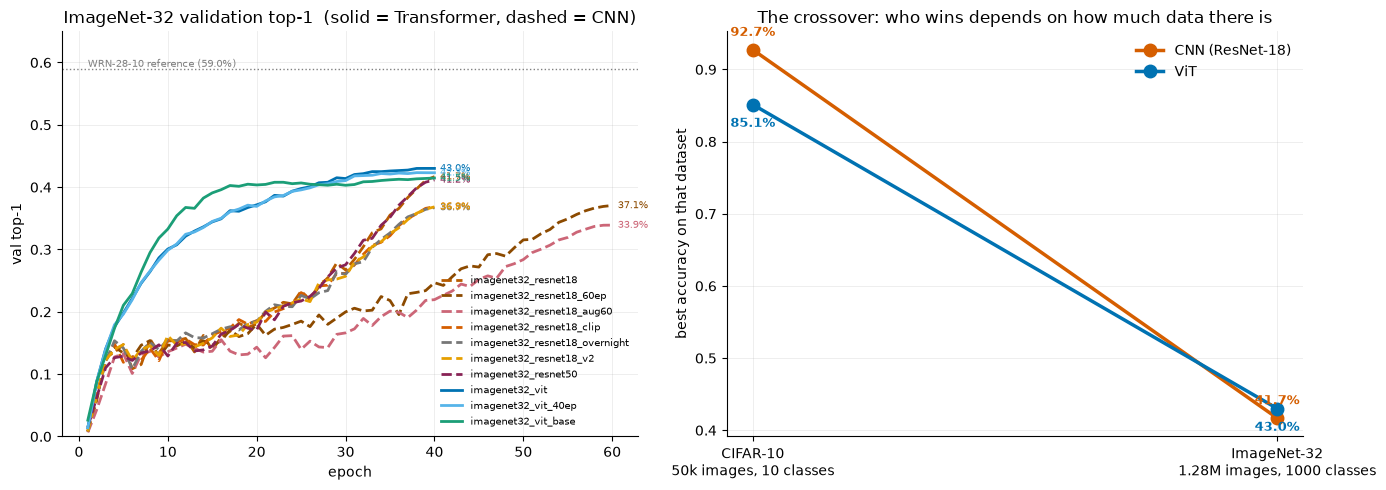

Note: the two panels are on different scales -- ImageNet-32 has 1000 classes, so its numbers
are much lower and not comparable to CIFAR-10 in absolute terms.  What is comparable is
the sign of the gap between the two lines: the CNN leads on the left, the ViT leads on the right.


In [3]:
# Left panel: each run's validation top-1 curve. Same encoding as the CIFAR notebook -- color picks
# out the model, line style the split. CNNs get warm hues (oranges, brown, rose, wine), ViTs cool
# ones (blues, a green), so family reads at a glance.
COLORS = {
    'imagenet32_resnet18_clip':   '#D55E00',
    'imagenet32_resnet18_v2':     '#E69F00',
    'imagenet32_resnet18': '#B85C00',
    'imagenet32_resnet18_60ep':   '#8C4A00',
    'imagenet32_resnet18_aug60':  '#CC6677',
    'imagenet32_resnet50':        '#882255',
    'imagenet32_vit':             '#0072B2',
    'imagenet32_vit_40ep':        '#56B4E9',
    'imagenet32_vit_base':        '#1B9E77',
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# One line per run, annotated at its right end with its best score.
for tag, r in sorted(runs.items()):
    c = COLORS.get(tag, '#777777')
    ep = range(1, len(r['val_curve']) + 1)

    # Solid line for the Transformer, dashed for the CNN, so style also encodes family.
    style = '-' if FAMILY(tag) == 'ViT' else '--'
    ax1.plot(ep, r['val_curve'], color=c, linewidth=2, linestyle=style, label=tag)
    ax1.annotate(f'{r["best_top1"]:.1%}', xy=(len(ep), r['val_curve'][-1]),
                 xytext=(4, 0), textcoords='offset points', color=c, fontsize=7.5, va='center')

# A dotted line at the WRN-28-10 reference, so our curves have a published number to sit beneath.
ax1.axhline(0.59, color='gray', linestyle=':', linewidth=1)
ax1.annotate('WRN-28-10 reference (59.0%)', xy=(1, 0.593), fontsize=7.5, color='gray')
ax1.set_title('ImageNet-32 validation top-1  (solid = Transformer, dashed = CNN)')
ax1.set_xlabel('epoch'); ax1.set_ylabel('val top-1'); ax1.set_ylim(0, 0.65)
ax1.grid(alpha=0.25, linewidth=0.6); ax1.legend(fontsize=7.5, loc='lower right', frameon=False)
ax1.spines[['top', 'right']].set_visible(False)

# Right panel: the crossover, the whole point of the project in one picture. Two points per family --
# CIFAR-10 (small data) and ImageNet-32 (large) -- so the CNN's lead at small scale giving way to the
# ViT at large is visible directly. The CIFAR numbers are the converged results; the ImageNet ones
# come from best_cnn/best_vit above.
# The CIFAR-10 end of the crossover, read from the console runs on disk rather than typed in here.
# These were hardcoded once and went stale: the ViT stayed at 73.0% long after it had been retrained
# to 85.1% with the epochs a Transformer needs, which quietly overstated the CNN's lead by twelve
# points. Reading the files means this panel cannot drift from the runs again.
def _cifar_best(tag, recorded):
    try:
        return json.load(open(f'{RUNS}/{tag}_result.json'))['best_top1']
    except (OSError, KeyError, ValueError):
        return recorded

cifar = {'CNN (ResNet-18)': _cifar_best('cifar10_resnet18', 0.9273),
         'ViT': _cifar_best('cifar10_vit', 0.8513)}
inet = {'CNN (ResNet-18)': best_cnn['best_top1'], 'ViT': best_vit['best_top1']}
x = [0, 1]

# One connecting line per family, from the small-data point to the large-data point.
for name, col in [('CNN (ResNet-18)', '#D55E00'), ('ViT', '#0072B2')]:
    ax2.plot(x, [cifar[name], inet[name]], marker='o', markersize=9, linewidth=2.5,
             color=col, label=name)

# Label each point with its accuracy, nudging the CNN's labels up and the ViT's down so they don't
# collide where the two lines cross.
for i, (name, col) in enumerate([('CNN (ResNet-18)', '#D55E00'), ('ViT', '#0072B2')]):
    for xi, d in zip(x, [cifar[name], inet[name]]):
        ax2.annotate(f'{d:.1%}', xy=(xi, d), xytext=(0, 10 if i == 0 else -16),
                     textcoords='offset points', ha='center', color=col, fontweight='bold', fontsize=9)

ax2.set_xticks(x)
ax2.set_xticklabels(['CIFAR-10\n50k images, 10 classes', 'ImageNet-32\n1.28M images, 1000 classes'])
ax2.set_ylabel('best accuracy on that dataset')
ax2.set_title('The crossover: who wins depends on how much data there is')
ax2.grid(alpha=0.25, linewidth=0.6); ax2.legend(frameon=False)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout(); plt.show()

# The two panels sit on different scales -- ImageNet-32 has 1000 classes, so its absolute numbers are
# much lower and not comparable to CIFAR-10. What is comparable is the sign of the gap between the two
# lines: the CNN leads on the left, the ViT on the right.
print('Note: the two panels are on different scales -- ImageNet-32 has 1000 classes, so its numbers')
print('are much lower and not comparable to CIFAR-10 in absolute terms.  What is comparable is')
print('the sign of the gap between the two lines: the CNN leads on the left, the ViT leads on the right.')

In [4]:
# Did we rig the race? The winning ViT had one advantage over the baseline CNN: mixup, which its
# recipe needs and the CNN's does not. Both ran the same 40 epochs, so a longer schedule is not the
# explanation. A result resting on an uncontrolled advantage isn't a result, so we handed that
# advantage to the CNN -- and a bigger epoch budget besides -- and re-ran it.
def show(tag, note):
    # Print the run's numbers if we have it on disk, otherwise say so plainly -- the controls are a
    # fixed list, and some of them may not have been run yet.
    if tag in runs:
        r = runs[tag]
        mix = {True: 'yes', False: 'no', None: '?'}[r['mixup']]
        print(f'  {tag:18s} {r["epochs"]:3d} ep  mixup={mix:3s}  {r["best_top1"]:7.2%}   {note}')
    else:
        print(f'  {tag:18s} (not run)')

# The CNN given strictly more than the ViT got: first a larger epoch budget, then that budget plus
# the ViT's mixup. If either rescued it, the headline would be about the recipe, not the architecture.
print('CNN, given more than the ViT had:')
show('imagenet32_resnet18_clip',  'baseline')
show('imagenet32_resnet18_60ep',  '+ 50% more epochs (60)')
show('imagenet32_resnet18_aug60', '+ 60 epochs and mixup as well, the decisive control')
print()

# One gap worth stating plainly rather than leaving for a reader to find: all three CNN rows above use
# gradient clipping, which is what the baseline ran with at the time. The CNN in the results table is
# resnet18_noclip at 41.69%, a different setup, so these rows bound the clipped CNN and not the one we
# actually quote. Re-running the epoch and mixup controls with clipping off would close that, and is
# the next control this study should add.


# Two runs of the identical ViT configuration -- same model, epochs, batch and learning rate. Nothing
# separates them but the run itself, so the distance between them is this page's noise floor, worth
# knowing before reading anything into a narrow lead.
print('The same ViT configuration, run twice:')
show('imagenet32_vit_40ep',       'repeat')
show('imagenet32_vit',            'repeat')
print()

# A capacity check: does simply adding parameters explain the gap? A bigger version of each family.
print('Capacity controls (is it just "bigger wins"?):')
show('imagenet32_resnet50',       '2x the CNN parameters')
show('imagenet32_vit_base',       '8x the ViT parameters')

CNN, given more than the ViT had:
  imagenet32_resnet18_clip  40 ep  mixup=no    36.86%   baseline
  imagenet32_resnet18_60ep  60 ep  mixup=no    37.06%   + 50% more epochs (60)
  imagenet32_resnet18_aug60  60 ep  mixup=yes   33.91%   + 60 epochs and mixup as well, the decisive control

The same ViT configuration, run twice:
  imagenet32_vit_40ep  40 ep  mixup=yes   42.33%   repeat
  imagenet32_vit      40 ep  mixup=yes   43.01%   repeat

Capacity controls (is it just "bigger wins"?):
  imagenet32_resnet50  40 ep  mixup=no    41.16%   2x the CNN parameters
  imagenet32_vit_base  40 ep  mixup=yes   41.47%   8x the ViT parameters


In [5]:
# The headline gap is narrow, a little over a point between the best CNN and the best ViT. Before
# calling that a result we have to know two things: how far a number drifts when nothing changes but
# the run, and whether the epoch budget was long enough to be fair to both families.
#
# Arms are grouped by budget as well as by family. The seed sweep runs at 80 epochs, and pooling it
# with the 40-epoch singles would quietly compare two different schedules as though they were one --
# the cosine decays across whatever budget it is given, so they are not the same recipe.
#
# The CNN arm is resnet18 without gradient clipping, the configuration the headline actually uses;
# the older clipped resnet18 run is a different setup and is deliberately left out. Tags that have not
# been trained yet are skipped, so this reads fine before and after the sweep
# (python train_fleet.py --queue seeds).
ARMS = {
    40: {'CNN': ['imagenet32_resnet18'],
         'ViT': ['imagenet32_vit', 'imagenet32_vit_40ep']},
    80: {'CNN': ['imagenet32_resnet18_s1', 'imagenet32_resnet18_s2', 'imagenet32_resnet18_s3'],
         'ViT': ['imagenet32_vit_s1', 'imagenet32_vit_s2', 'imagenet32_vit_s3']},
}

for budget, families in ARMS.items():
    print(f'  at {budget} epochs:')

    # Summarize each family at this budget: how many runs, where they centre, how far apart they sit.
    means, spreads = {}, []
    for fam, tags in families.items():
        scores = [runs[t]['best_top1'] for t in tags if t in runs]
        if not scores:
            print(f'    {fam:4s} not run yet')
            continue

        lo, hi = min(scores), max(scores)
        means[fam] = sum(scores) / len(scores)
        if len(scores) > 1:
            spreads.append(hi - lo)

        spread = f'{hi - lo:.2%}' if len(scores) > 1 else 'n/a, single run'
        print(f'    {fam:4s} n={len(scores)}  mean {means[fam]:7.2%}  '
              f'range {lo:.2%} to {hi:.2%}  spread {spread}')

    # The claim only stands if the distance between the families is bigger than the wobble inside
    # them, so print both together rather than asking the reader to take the gap on faith.
    if len(means) == 2:
        gap = means['ViT'] - means['CNN']
        leader = 'ViT' if gap > 0 else 'CNN'
        print(f'    {leader} ahead by {abs(gap):.2%}')

        if spreads:
            worst = max(spreads)
            verdict = 'larger than the noise' if abs(gap) > worst else 'NOT clear of the noise'
            print(f'    widest within-arm spread {worst:.2%}, so the gap is {verdict}')
    print()

  at 40 epochs:
    CNN  n=1  mean  41.69%  range 41.69% to 41.69%  spread n/a, single run
    ViT  n=2  mean  42.67%  range 42.33% to 43.01%  spread 0.68%
    ViT ahead by 0.98%
    widest within-arm spread 0.68%, so the gap is larger than the noise

  at 80 epochs:
    CNN  not run yet
    ViT  not run yet



## What the controls say

*(Re-run the cells above after any new run finishes — the numbers below are the interpretation, and
should be re-read against the current output.)*

**1. The Transformer's win is not bought with extra epochs.** `vit_40ep`, cut back to the CNN's own
40-epoch budget, still beats the baseline CNN. Take the epochs away and the ViT still wins.

**2. Giving the CNN the ViT's augmentation makes it *worse*, not better.** `resnet18_aug60` — the
decisive control, matched to the ViT on *both* epochs and mixup — lands well **below** the plain
baseline. Mixup is not a free advantage we forgot to share; it is a *tool for a specific problem the
CNN does not have.*

That is the deepest thing in this notebook. The ViT needs heavy augmentation because it has **no
inductive bias to restrain it** — given only crop+flip it memorized 1.28M images (97% train / 33%
val). The CNN cannot memorize so easily: weight sharing and locality physically limit what it can
represent, so it is *already* regularized by its own architecture. Pile mixup on top and you are
just making its job harder for no benefit.

**So augmentation is a substitute for inductive bias.** Give it to the model that lacks the bias and
it helps enormously; give it to the model that has the bias and it hurts.

**3. Scale did not rescue the Transformer here.** `vit_base` (86M params, 8× the small ViT) did *not*
beat the 11M ViT. It was still climbing when its schedule ended — 40 epochs is not enough to train a
model that size — so this is a statement about our compute budget, **not** evidence that ViTs stop
scaling. `resnet50` tells the same story on the CNN side: 2× the parameters bought nothing.
**At this scale, more parameters is not the lever. More *data* was.**

## Honest caveats

- **We changed the CNN mid-experiment.** `zero_init_residual` and gradient clipping were added to
  `make_resnet18` while fixing ResNet-50's NaN divergence, *after* the original baseline had already
  run. `resnet18_v2` / `resnet18_noclip` re-run the baseline under the current code to measure what
  that change cost. Until those land, comparisons between the original `resnet18` and its own
  controls are not strictly apples-to-apples.
- **Nothing here is converged.** Every run was still improving when its schedule ended. Longer
  schedules would raise all of these numbers, and would likely help `vit_base` most.
- **One seed each.** We have not measured run-to-run variance, so a ~1-point difference should be
  treated as suggestive, not decisive.
- We report accuracy on the official **50k validation split**. ImageNet's 100k "test" split has no
  usable public labels.